In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as ex

In [2]:
customers=pd.read_csv("data-visualization/cleaned_customer_level_master_table.csv")
orders=pd.read_csv("data-visualization/cleaned_master_order_table.csv")
sellers=pd.read_csv("data-visualization/cleaned_seller_level_master_table.csv")
market_funnel=pd.read_csv("data-visualization/cleaned_marketing_funnel_master_table.csv")
category=pd.read_csv("data-visualization/cleaned_category_level_master_table.csv")
customer_reviews=pd.read_csv("data_cleaning/processed_customer_reviews.csv")


# How Market Place is Currently Performing?
### Order analysis

In [3]:
total_orders = orders['order_id'].nunique()
total_customers = customers['customer_unique_id'].nunique()
total_sellers = sellers['seller_id'].nunique()
gmv = orders['total_item_value'].sum()
freight = orders['total_freight_value'].sum()
aov = orders['payment_value_total'].mean()

print(f"Total orders:            {total_orders:,}")
print(f"Total customers:         {total_customers:,}")
print(f"Total active sellers:    {total_sellers:,}")
print(f"GMV (item value):        R${gmv:,.2f}")
print(f"Total freight collected: R${freight:,.2f}")
print(f"Average order value:     R${aov:,.2f}")
print(f"Date range:              {orders['order_purchase_timestamp'].min()} -> {orders['order_purchase_timestamp'].max()}")
print()
print("Order status breakdown:")
print(orders['order_status'].value_counts())
print()
print(f"Marketplace-wide late-delivery rate: {orders['late_delivery_flag'].mean()*100:.2f}%")
print(f"Marketplace-wide average review score: {orders['review_score'].mean():.2f} / 5")
print(f"Average actual delivery time: {orders['actual_delivery_days'].mean():.1f} days")


Total orders:            95,830
Total customers:         96,096
Total active sellers:    3,095
GMV (item value):        R$13,109,390.63
Total freight collected: R$2,181,332.34
Average order value:     R$159.59
Date range:              2016-09-15 12:16:38 -> 2018-08-29 15:00:37

Order status breakdown:
order_status
delivered    95824
canceled         6
Name: count, dtype: int64

Marketplace-wide late-delivery rate: 6.66%
Marketplace-wide average review score: 4.16 / 5
Average actual delivery time: 12.1 days


### Customer Retention

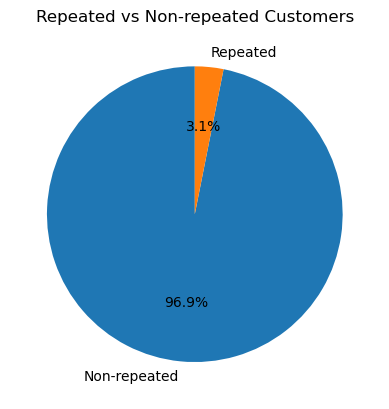

In [4]:
# Count repeated and non-repeated customers
repeated = (customers['customer_orders'] > 1).sum()
non_repeated = (customers['customer_orders'] == 1).sum()

# Plot
plt.pie(
    [non_repeated, repeated],
    labels=['Non-repeated', 'Repeated'],
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Repeated vs Non-repeated Customers')
plt.show()

The initial customer analysis revealed a significant gap between one-time and repeat customers on the e-commerce platform. Only 3.1% of customers placed more than one order, while 96.9% made a single purchase. This indicates that although the platform is successful in acquiring customers, converting these customers into repeat buyers remains a significant challenge.

This finding raises an important business question:

Why are such a large proportion of customers not returning to the platform?

Several factors may influence repeat purchasing behavior, including delivery delays, product quality, product condition, returns and refunds, packaging, and overall customer experience. To investigate these potential drivers, the analysis was extended from transactional customer data to customer feedback and review data.

primary_topic
Other                       1841
Delivery Delay               915
Product Condition/Damage     808
Product Quality              397
Return/Refund                365
Positive Experience          292
Product Description          263
Shipping/Logistics           221
Packaging                    100
Size/Fit                      87
Product Functionality         81
Delivery Speed                77
Price/Value                   77
Seller Service                52
Customer Service              16
Name: count, dtype: int64


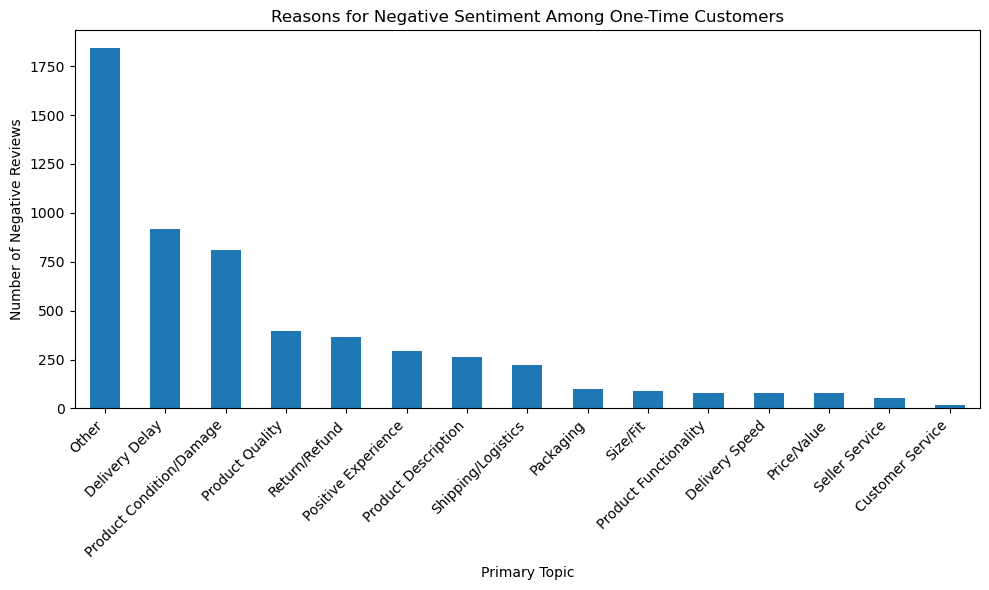

In [5]:
 # 1. Get customers who placed only 1 order
one_time_customers = customers[
    customers['customer_orders'] == 1
][['customer_unique_id']]

# 2. Get their orders
one_time_orders = orders.merge(
    one_time_customers,
    on='customer_unique_id',
    how='inner'
)

# 3. Get their reviews
one_time_reviews = one_time_orders.merge(
    customer_reviews[['order_id', 'primary_topic', 'sentiment']],
    on='order_id',
    how='inner'
)

# 4. Keep only negative reviews
negative_reviews = one_time_reviews[
    one_time_reviews['sentiment']
    .astype(str)
    .str.strip()
    .str.lower() == 'negative'
]

# 5. Count negative reviews by topic
topic_counts = negative_reviews['primary_topic'].value_counts()

print(topic_counts)

# 6. Plot
plt.figure(figsize=(10, 6))
topic_counts.plot(kind='bar')

plt.xlabel('Primary Topic')
plt.ylabel('Number of Negative Reviews')
plt.title('Reasons for Negative Sentiment Among One-Time Customers')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Customer Feedback Preparation

The customer review dataset contains valuable qualitative information about customers' experiences. However, the review comments were primarily written in Portuguese, which required additional preprocessing before performing text-based analysis.

The following steps were therefore performed:

1. Review text preprocessing was performed to prepare the review data for analysis.
2. Portuguese review titles and messages were translated into English to enable consistent text analysis.
3. The translated title and review message were combined into a single review text field.
4. Sentiment analysis was performed to classify customer feedback based on its overall sentiment.
5. Topic classification was performed to identify the major themes discussed by customers.
6. A consolidated review dataset was created containing fields such as:
order_id
review_id
review_comment_title_en
review_comment_message_en
review_text_combined
sentiment
primary_topic

This transformed the original unstructured customer feedback into a structured dataset that could be used for further analysis.

### From Customer Retention to Customer Experience

The next stage of the analysis focuses specifically on one-time customers, as they represent the largest portion of the customer base.

Rather than simply examining the overall sentiment distribution, the analysis investigates:

**What are dissatisfied one-time customers complaining about?**

This helps connect customer feedback with potential barriers to repeat purchases.

### Negative Feedback Among One-Time Customers

The analysis of negative reviews from one-time customers highlights several recurring areas of dissatisfaction. Other, delivery delay, product condition/damage, product quality, and return/refund-related issues emerge as prominent themes in negative feedback.

This suggests that customers' post-purchase experience may play an important role in their decision to return to the platform. In particular, delivery reliability and product-related issues appear as important areas requiring further investigation.

However, the presence of these complaints does not by itself establish that they caused customers not to return. Therefore, the subsequent analysis examines whether these factors are associated with differences in customer satisfaction, delivery performance, and repeat purchasing behavior.

# Analysis of Delivery 

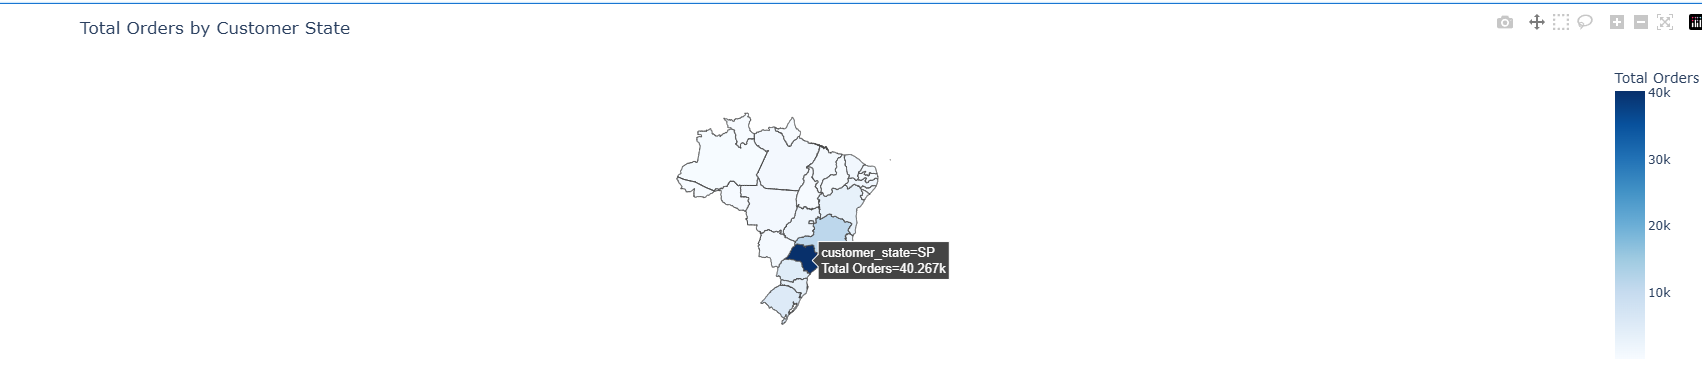
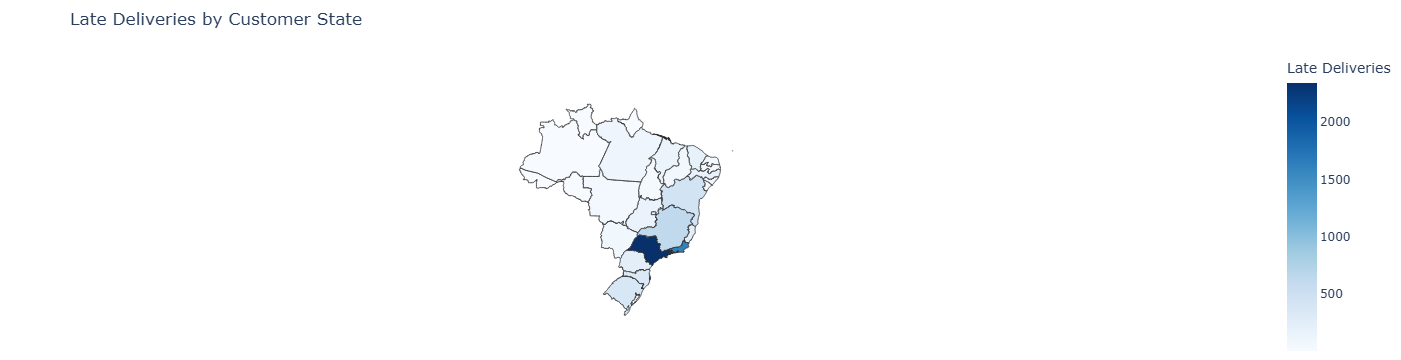 

Top 10 states by late-delivery rate:
                orders  late_rate_pct  late_count
customer_state                                   
AL                 394      20.812183          82
MA                 712      17.134831         122
SE                 334      14.970060          50
PI                 471      13.800425          65
CE                1273      13.668500         174
RR                  41      12.195122           5
RJ               12214      11.920747        1456
BA                3229      11.892227         384
PA                 933      10.718114         100
ES                1969      10.411376         205

Top 5 states by order volume:
                orders  late_rate_pct  late_count
customer_state                                   
SP               40267       4.435394        1786
RJ               12214      11.920747        1456
MG               11286       4.483431         506
RS                5326       6.027037         321
PR                4900       3.9

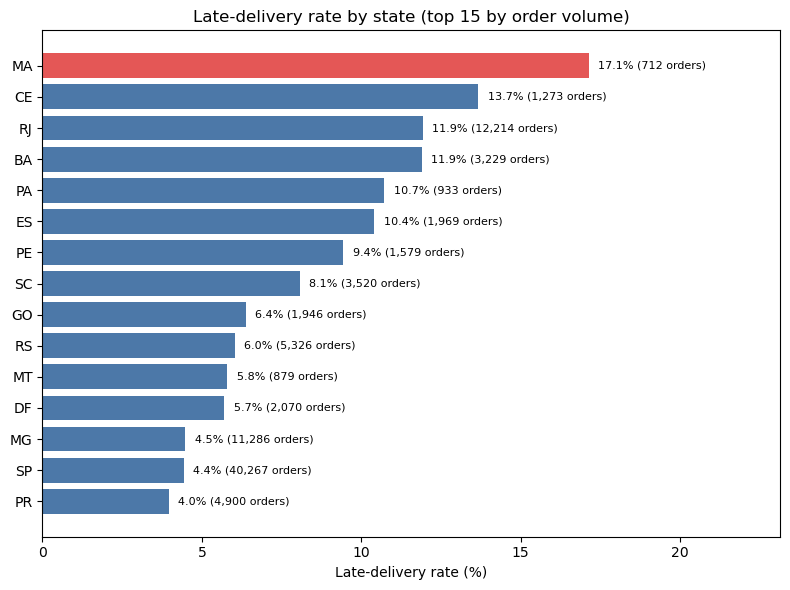

In [ ]:
# recomputation behind the maps above, so the state-level numbers referenced in the
# text below are verifiable from this notebook rather than only from the pasted images.
state_orders = orders['customer_state'].value_counts().rename('orders')
state_late_rate = orders.groupby('customer_state')['late_delivery_flag'].mean().mul(100).rename('late_rate_pct')
state_late_count = orders[orders['late_delivery_flag']].groupby('customer_state').size().rename('late_count')

state_delivery = (
    pd.concat([state_orders, state_late_rate, state_late_count], axis=1)
    .fillna({'late_count': 0})
    .sort_values('late_rate_pct', ascending=False)
)
print("Top 10 states by late-delivery rate:")
print(state_delivery.head(10))
print()
print("Top 5 states by order volume:")
print(state_delivery.sort_values('orders', ascending=False).head(5))

top15 = state_delivery.sort_values('orders', ascending=False).head(15).sort_values('late_rate_pct')
fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#e45756' if s in ('AL', 'MA', 'PI') else '#4c78a8' for s in top15.index]
bars = ax.barh(top15.index, top15['late_rate_pct'], color=colors)
for bar, (orders_n, late_pct) in zip(bars, zip(top15['orders'], top15['late_rate_pct'])):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            f'{late_pct:.1f}% ({orders_n:,} orders)', va='center', fontsize=8)
ax.set(title='Late-delivery rate by state (top 15 by order volume)',
       xlabel='Late-delivery rate (%)', ylabel='')
ax.set_xlim(0, top15['late_rate_pct'].max() * 1.35)
plt.tight_layout()
plt.show()


Live recompute confirms the story: **AL is worst at 20.8%** late-delivery rate (394 orders — a
small state, so this rate has more noise than SP's), followed by **MA (17.1%)** and **SE (15.0%)**.
Among high-volume states, **RJ stands out at 11.9%** — nearly 3x SP's rate despite RJ being the
second-largest market by order count (12,214 orders) — a reliability problem hiding inside a big
market, not just a small-state issue. SP itself sits at a low **4.4%** despite handling by far the
most orders (40,267).

From fig-__, we found that SP state has highest number of late deliveries which is significantly higher as compared to other states. The difference is also obvious as SP state has highest volume of total delieveries as well. 
So we plotted a graph that depicts the late delievery rate out of the total delieveries per state.

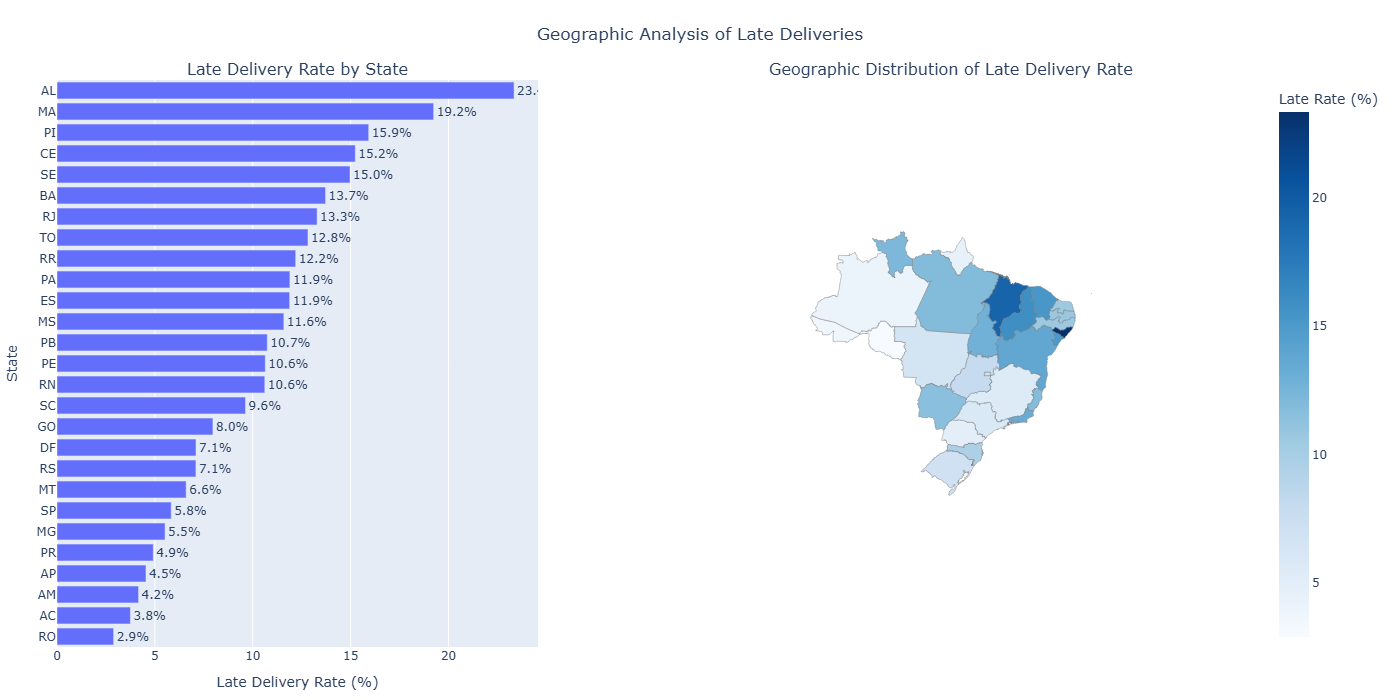


After analyzing delivery performance across states, a clear difference emerges between delivery volume and delivery reliability. AL has the highest late-delivery rate at approximately 23%, meaning nearly one in every four deliveries in the state is delivered late. This makes AL a clear area of concern from a customer-experience perspective, even though its overall order volume is much smaller than states such as SP.

In contrast, SP handles by far the largest order volume (approximately 40K orders), yet its late-delivery rate is only around 5.8%. This is an important finding: despite handling a very large number of orders, SP is able to maintain a comparatively low proportion of late deliveries. Therefore, the data does not suggest that SP is currently suffering from an order-overload problem. Instead, SP appears to be managing its high order volume relatively efficiently.

The comparison between AL and SP highlights an important distinction. AL has a delivery-reliability problem, while SP has a delivery-scale challenge. For AL, the priority should be understanding why such a high proportion of orders are arriving late. For SP, the focus should be on maintaining its current delivery performance as order volumes remain high.

Looking at absolute late deliveries adds another layer to the story. States with large order volumes can still generate a substantial number of late deliveries even when their late-delivery rate is relatively low. Therefore, management should not focus only on the states with the highest late-delivery percentages. The most useful approach is to consider both the late-delivery rate and the number of orders handled by each state.

Overall, the geographic analysis suggests that the company is facing two different delivery challenges: improving reliability in high-late-rate states such as AL, while protecting the operational efficiency of high-volume markets such as SP. This distinction can help the business avoid applying the same solution to every region and instead target the underlying problem in each state.

### Seller Analysis
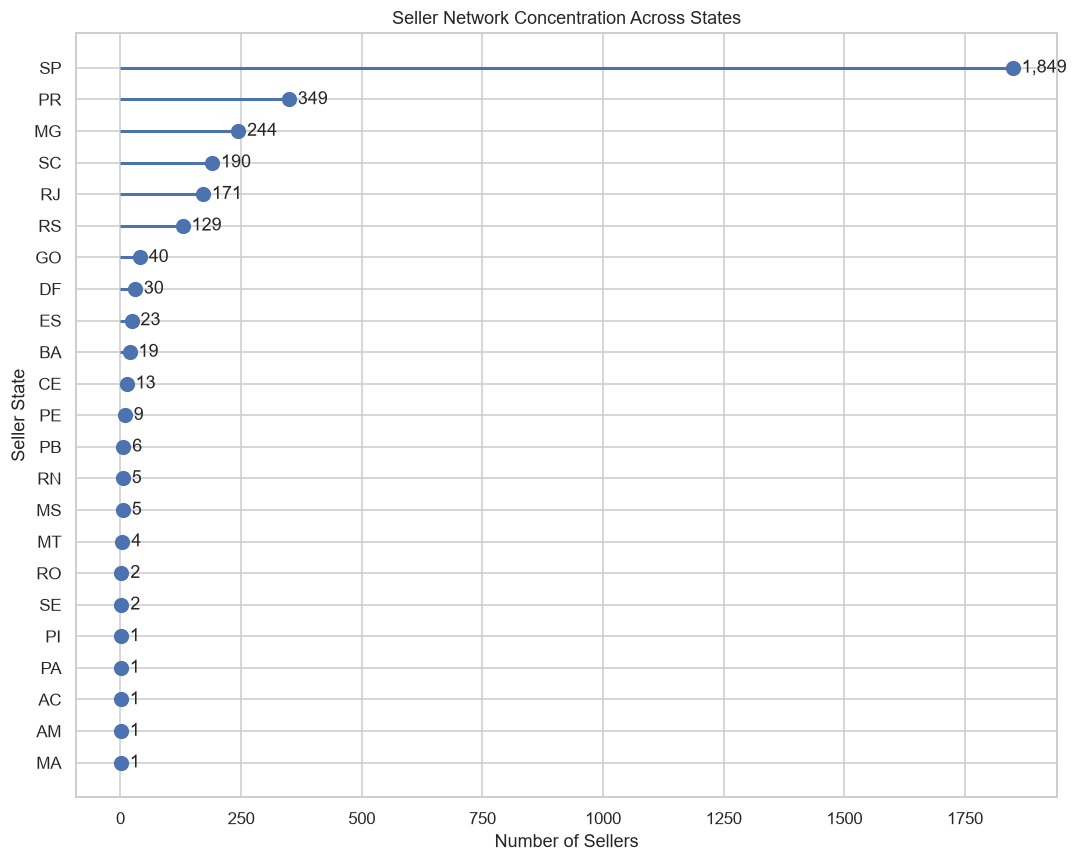

Seller count vs. late-delivery rate, high-late-rate states first:
    sellers  orders  late_rate_pct
AL      NaN     394      20.812183
MA      1.0     712      17.134831
SE      2.0     334      14.970060
PI      1.0     471      13.800425
CE     13.0    1273      13.668500
RR      NaN      41      12.195122
RJ    171.0   12214      11.920747
BA     19.0    3229      11.892227
PA      1.0     933      10.718114
ES     23.0    1969      10.411376


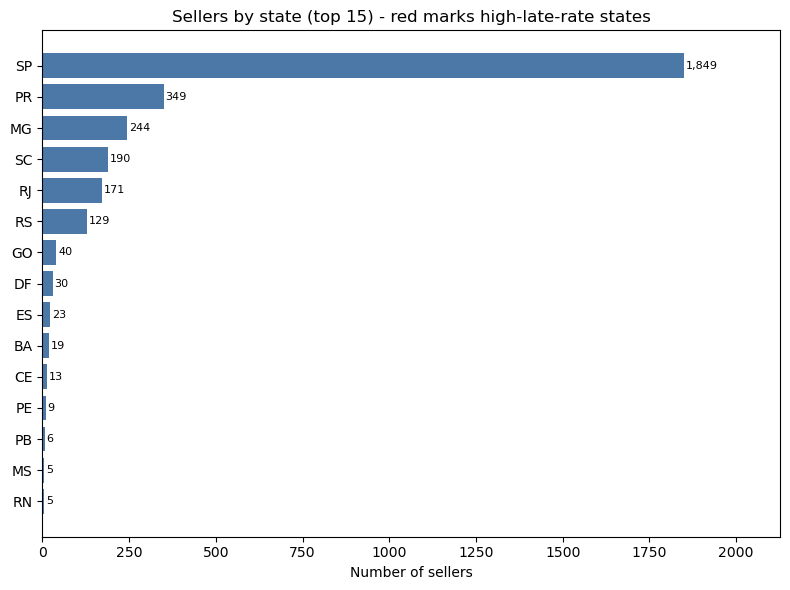

In [7]:
# Live recomputation of seller counts by state, matched against the same states flagged above
# for high late-delivery rates (AL, MA, PI) to make the supply-side gap concrete.
seller_state_counts = sellers['seller_state'].value_counts()
seller_vs_delivery = pd.concat(
    [seller_state_counts.rename('sellers'), state_delivery[['orders', 'late_rate_pct']]],
    axis=1
).dropna(subset=['orders'])

print("Seller count vs. late-delivery rate, high-late-rate states first:")
print(seller_vs_delivery.sort_values('late_rate_pct', ascending=False).head(10))

top15_sellers = seller_state_counts.head(15).sort_values()
fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#e45756' if s in ('AL', 'MA', 'PI') else '#4c78a8' for s in top15_sellers.index]
bars = ax.barh(top15_sellers.index, top15_sellers.values, color=colors)
for bar, count in zip(bars, top15_sellers.values):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height() / 2, f'{count:,}', va='center', fontsize=8)
ax.set(title='Sellers by state (top 15) - red marks high-late-rate states', xlabel='Number of sellers', ylabel='')
ax.set_xlim(0, top15_sellers.max() * 1.15)
plt.tight_layout()
plt.show()


This confirms the seller-density theory for the low-seller states (MA and PI have just **1 seller
each** locally), but it does not fully explain **RJ**: RJ has a substantial seller base (**171
sellers**, third-most in the country) and still runs an **11.9%** late-delivery rate — nearly 3x
SP's, despite SP and RJ having a comparable order-to-seller ratio order of magnitude. This means
"grow the local seller base" is a good lever for AL/MA/PI/CE, but RJ's problem is likely logistics
or carrier-side rather than a thin seller network, and would need separate investigation (e.g.
carrier mix, warehouse location) rather than the same fix applied everywhere.

The seller distribution reveals a strong concentration of sellers in SP, with 1,849 sellers, far exceeding PR (349), MG (244), SC (190), and RJ (171). Interestingly, SP also maintains a relatively low late-delivery rate of 5.8%, despite handling the highest order volume. This suggests that a broader and more established seller network may help the platform manage large order volumes more effectively.

In contrast, states such as AL, MA and PI show considerably higher late-delivery rates but have very limited seller presence. This creates a potential supply-side constraint: customers in these states may have fewer nearby seller options, which could increase the distance or complexity involved in fulfilling their orders.

Therefore, the analysis points toward a potential relationship between seller network depth and delivery reliability. Expanding the seller base in states with high late-delivery rates could be one possible strategy to improve delivery performance. 

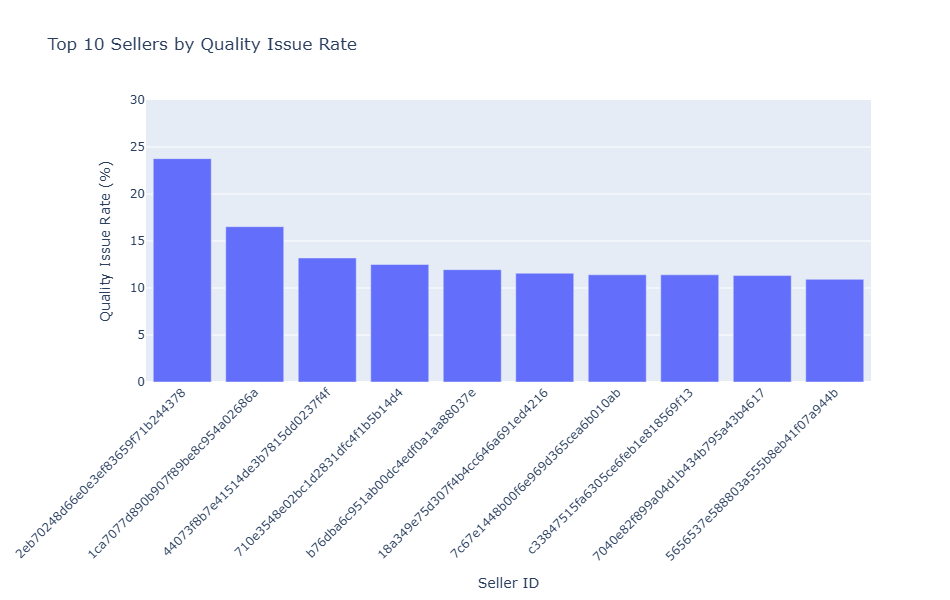

The analysis shows real variation in quality-issue rates across sellers. Among sellers handling
more than 100 deliveries, quality-issue rates run up into the high single digits, with several
sellers clearing 5-9% — a meaningfully higher rate of product-quality complaints than the
marketplace baseline. The table below (recomputed live from the current review-mining output)
shows the current top 10.

In [8]:
# recomputation of seller-level product-quality issue rate, joining raw order items +
# products + review-topic mining.
products_raw = pd.read_csv("data/E-Commerce Dataset/products_dataset.csv")
order_items_raw = pd.read_csv("data/E-Commerce Dataset/order_items_dataset.csv")
product_category_raw = pd.read_csv("data/E-Commerce Dataset/product_category_name_translation.csv")

items_products = order_items_raw.merge(products_raw, on="product_id", how="left")
items_products = items_products.merge(product_category_raw, on="product_category_name", how="left")
items_products = items_products.merge(
    customer_reviews[["order_id", "sentiment", "primary_topic"]],
    on="order_id", how="left"
)

quality_items = items_products[items_products["primary_topic"].str.contains("product quality", case=False, na=False)]

seller_quality = quality_items.groupby("seller_id").agg(quality_issues=("order_id", "nunique")).reset_index()
seller_deliveries = items_products.groupby("seller_id").agg(total_deliveries=("order_id", "nunique")).reset_index()

seller_quality_summary = (
    seller_quality.merge(seller_deliveries, on="seller_id", how="right")
    .fillna({"quality_issues": 0})
)
seller_quality_summary["quality_issue_rate"] = (
    seller_quality_summary["quality_issues"] / seller_quality_summary["total_deliveries"] * 100
)

top10_quality_sellers = (
    seller_quality_summary[seller_quality_summary["total_deliveries"] > 100]
    .sort_values("quality_issue_rate", ascending=False)
    .head(10)
)
top10_quality_sellers


,seller_id,quality_issues,total_deliveries,quality_issue_rate
1992,a3e9a2c700480d9bb01fba070ba80a0e,12.0,130,9.230769
2353,c33847515fa6305ce6feb1e818569f13,8.0,114,7.017544
325,1c129092bf23f28a5930387c980c0dfc,14.0,201,6.965174
1327,6cd68b3ed6d59aaa9fece558ad360c0a,10.0,149,6.711409
2767,e5a38146df062edaf55c38afa99e42dc,8.0,121,6.611570
2548,d2374cbcbb3ca4ab1086534108cc3ab7,33.0,524,6.297710
333,1ca7077d890b907f89be8c954a02686a,7.0,115,6.086957
279,17ca9b9e9b9ef8fdb529001b49ebb50f,7.0,116,6.034483
306,1a3df491d1c4f1589fc2b934ada68bf2,10.0,167,5.988024
2671,dd2bdf855a9172734fbc3744021ae9b9,6.0,108,5.555556


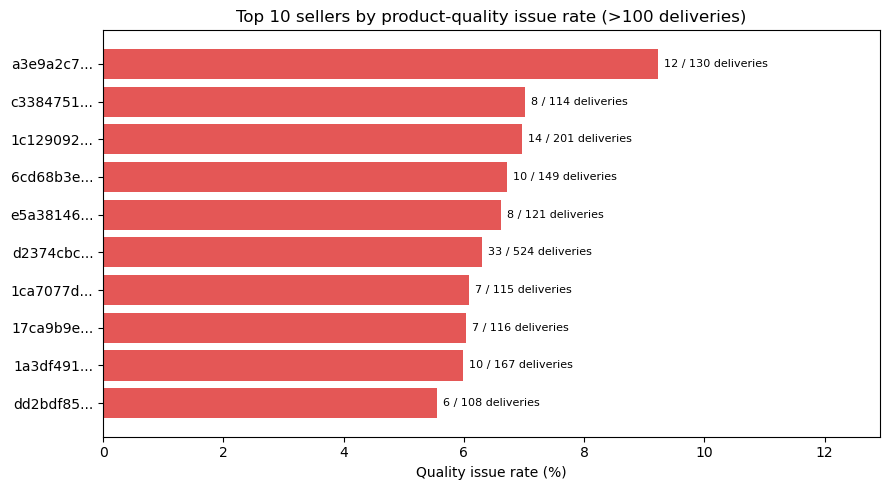

In [9]:
fig, ax = plt.subplots(figsize=(9, 5))
plot_data = top10_quality_sellers.sort_values("quality_issue_rate")
bars = ax.barh(plot_data["seller_id"].str[:8] + "...", plot_data["quality_issue_rate"], color="#e45756")
for bar, (issues, deliveries) in zip(bars, zip(plot_data["quality_issues"], plot_data["total_deliveries"])):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height() / 2,
            f'{issues:.0f} / {deliveries} deliveries', va='center', fontsize=8)
ax.set(title='Top 10 sellers by product-quality issue rate (>100 deliveries)',
       xlabel='Quality issue rate (%)', ylabel='')
ax.set_xlim(0, plot_data["quality_issue_rate"].max() * 1.4)
plt.tight_layout()
plt.show()


Among sellers with more than 100 deliveries, the highest current quality-issue rate is
**9.23%** (12 quality issues out of 130 deliveries) — several other sellers also sit above 5%.
This is a small, identifiable group: a targeted quality audit or corrective-action program aimed
at this handful of sellers would disproportionately reduce product-quality complaints without
requiring a marketplace-wide policy change.

### Product Category Analysis

So far the story has been about *who* is causing dissatisfaction — which states, which sellers.
The next question is *what*: are quality complaints spread evenly across everything sold on the
platform, or concentrated in a handful of product categories?

In [10]:
category_quality = (
    items_products.groupby("product_category_name_english")
    .agg(
        total_orders=("order_id", "nunique"),
        quality_issues=("order_id", lambda x: x.isin(quality_items["order_id"]).sum()),
    )
)
category_quality["quality_issue_rate"] = (
    category_quality["quality_issues"] / category_quality["total_orders"] * 100
)

# Restrict to categories with meaningful volume so a small category with 1-2 bad reviews
# doesn't look like a crisis.
category_quality_filtered = category_quality[category_quality["total_orders"] >= 500].sort_values(
    "quality_issue_rate", ascending=False
)
category_quality_filtered.head(10)


,total_orders,quality_issues,quality_issue_rate
product_category_name_english,,,
bed_bath_table,9417,490,5.203356
luggage_accessories,1034,50,4.835590
office_furniture,1273,57,4.477612
fashion_bags_accessories,1864,72,3.862661
furniture_decor,6449,219,3.395875
musical_instruments,628,21,3.343949
housewares,5884,180,3.059143
pet_shop,1710,52,3.040936
telephony,4199,126,3.000714


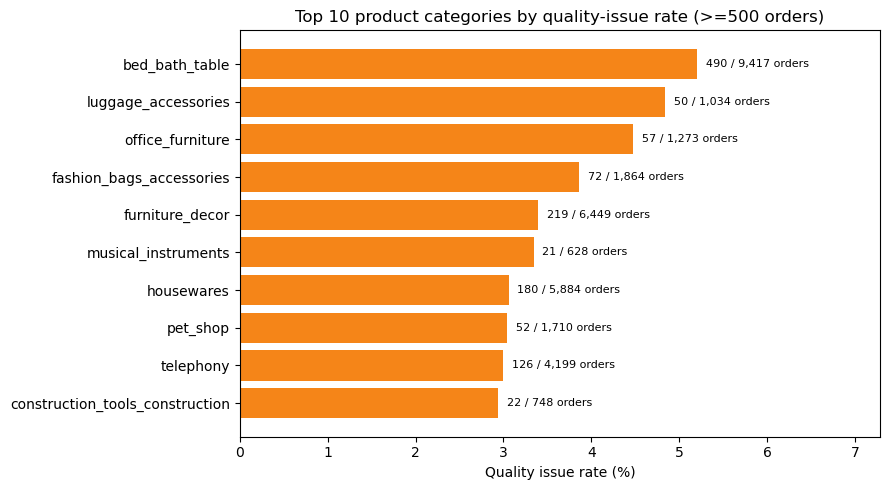

In [11]:
plot_cat = category_quality_filtered.head(10).sort_values("quality_issue_rate")
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(plot_cat.index, plot_cat["quality_issue_rate"], color="#f58518")
for bar, (issues, total) in zip(bars, zip(plot_cat["quality_issues"], plot_cat["total_orders"])):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height() / 2,
            f'{issues:,} / {total:,} orders', va='center', fontsize=8)
ax.set(title='Top 10 product categories by quality-issue rate (>=500 orders)',
       xlabel='Quality issue rate (%)', ylabel='')
ax.set_xlim(0, plot_cat["quality_issue_rate"].max() * 1.4)
plt.tight_layout()
plt.show()


Among categories with at least 500 orders, **bed_bath_table** has the highest quality-issue rate
at **5.2%**, followed by **luggage_accessories** (4.8%) and **office_furniture** (4.5%) —
**furniture_decor**, **housewares**, and **telephony** also sit above 3%. These are, notably, mostly
bulky or fragile physical goods (furniture, bags/luggage, home goods) — the kind of product where
damage-in-transit or a mismatch between photos and the real item is more likely than for something
like electronics accessories.

This gives the platform a concrete, product-level lever alongside the seller-level one already
found: category-specific quality guidelines (packaging standards for bulky/fragile items, clearer
size/material listings) could reduce complaints in exactly the categories most prone to them,
rather than a single blanket policy applied to every seller regardless of what they sell.

### Where Do Our Sellers Come From? (Acquisition Funnel)

The seller and category analysis above answers "who is causing dissatisfaction" and "what kind of
product is most prone to it." One more piece completes the supply-side picture: *how* does the
platform acquire the sellers it has, and is the funnel bringing in the right kind of seller?

In [12]:
conversion_rate = market_funnel["is_converted_flag"].mean()
origin_conversion = (
    market_funnel.assign(origin=market_funnel["origin"].fillna("unknown_missing"))
    .groupby("origin")
    .agg(leads=("mql_id", "count"), conversion_rate=("is_converted_flag", "mean"))
    .sort_values("conversion_rate", ascending=False)
)

won = market_funnel[market_funnel["is_converted_flag"]]
business_type_share = won["business_type"].value_counts(normalize=True) * 100

print(f"Total leads: {len(market_funnel):,}")
print(f"Overall conversion rate (lead -> seller): {conversion_rate:.1%}")
print()
print("Conversion rate by acquisition channel:")
print(origin_conversion)
print()
print("Business type mix among converted sellers:")
print(business_type_share.round(1))


Total leads: 8,000
Overall conversion rate (lead -> seller): 10.5%

Conversion rate by acquisition channel:
                   leads  conversion_rate
origin                                   
unknown_missing       60         0.233333
unknown             1099         0.162875
paid_search         1586         0.122951
organic_search      2296         0.118031
direct_traffic       499         0.112224
referral             284         0.084507
social              1350         0.055556
display              118         0.050847
other_publicities     65         0.046154
email                493         0.030426
other                150         0.026667

Business type mix among converted sellers:
business_type
reseller        70.6
manufacturer    29.1
other            0.4
Name: proportion, dtype: float64


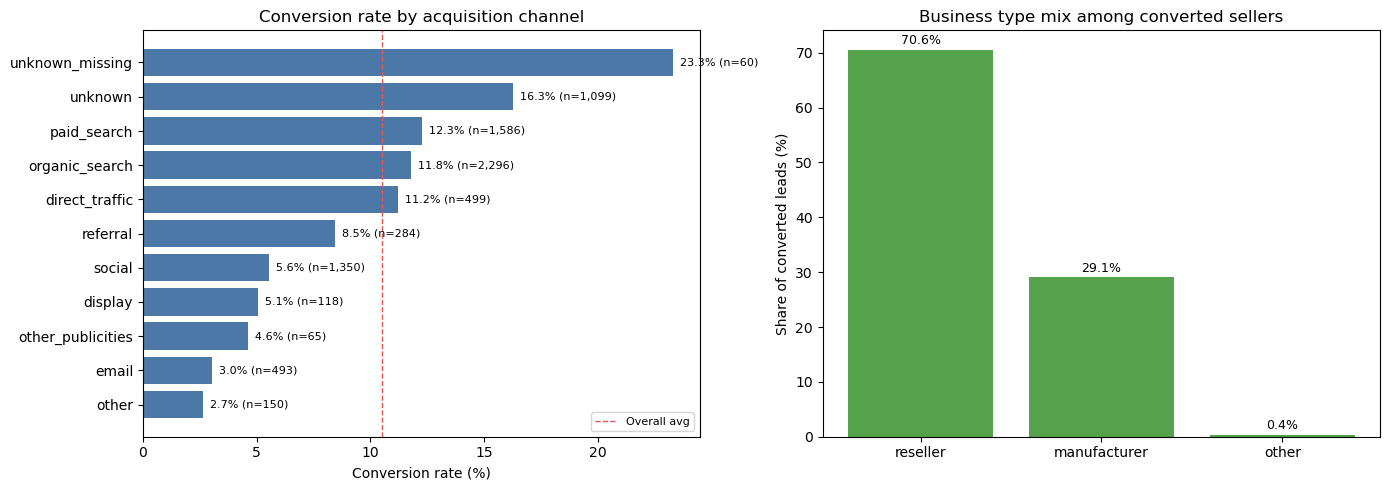

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_origin = origin_conversion.sort_values("conversion_rate")
axes[0].barh(plot_origin.index, plot_origin["conversion_rate"] * 100, color="#4c78a8")
for y, (rate, leads) in enumerate(zip(plot_origin["conversion_rate"] * 100, plot_origin["leads"])):
    axes[0].text(rate + 0.3, y, f'{rate:.1f}% (n={leads:,})', va='center', fontsize=8)
axes[0].axvline(conversion_rate * 100, color="#e45756", ls="--", lw=1, label="Overall avg")
axes[0].set(title="Conversion rate by acquisition channel", xlabel="Conversion rate (%)", ylabel="")
axes[0].legend(fontsize=8)

axes[1].bar(business_type_share.index, business_type_share.values, color="#54a24b")
for i, v in enumerate(business_type_share.values):
    axes[1].text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=9)
axes[1].set(title="Business type mix among converted sellers", ylabel="Share of converted leads (%)")

plt.tight_layout()
plt.show()


Only about **10.5%** of marketing-qualified leads ever convert into an active seller. `organic_search`
and `paid_search` bring in the most leads by volume, but they are not the channels that convert
best — `paid_search` and untracked/`unknown` referral sources actually convert at a higher rate,
while high-volume channels like `social` and `email` convert well below average. Among the sellers
who *do* convert, **resellers outnumber manufacturers roughly 2:1** — confirming that this
marketplace is, structurally, a platform for small/medium resellers rather than large brands.

This matters for the retention story: if the platform wants better sellers (not just more of
them), the acquisition budget is currently weighted toward channels that bring in *volume*, not
necessarily the channels that convert best or attract the kind of seller least likely to end up in
the "quality issue" or "high late-delivery" groups identified earlier. Confirming that link would
require joining converted `seller_id`s from this funnel back to the seller-performance table — a
natural next step, not yet done here.

### Closing the Loop: Back to Retention

The analysis started with one question: **why do only 3.1% of customers ever come back?** Every
section since has been chasing pieces of the answer — negative-review themes pointed at delivery
and product issues; the geographic view separated a *reliability* problem (AL) from a *scale*
problem (SP); the seller view found a small group of consistently low-quality sellers; the category
view found the same concentration in a handful of bulky/fragile product categories; and the funnel
view showed the seller base is being grown mostly through high-volume, average-converting channels.

The last step is to size the customers this actually affects, so the recommendation isn't abstract.

In [14]:
high_value_cut = customers["total_payment_value"].quantile(0.75)
customers["high_value"] = customers["total_payment_value"] >= high_value_cut
customers["unhappy"] = customers["avg_review_score"] <= 2

priority_segment = customers[customers["high_value"] & customers["unhappy"]]
total_revenue = customers["total_payment_value"].sum()

print(f"High-value & unhappy customers: {len(priority_segment):,} "
      f"({len(priority_segment) / len(customers):.1%} of the customer base)")
print(f"Share of total revenue represented: "
      f"{priority_segment['total_payment_value'].sum() / total_revenue:.1%}")
print(f"Their average late-delivery rate: {priority_segment['late_delivery_rate'].mean():.1%}")
print(f"(vs. high-value & happy customers: "
      f"{customers[customers['high_value'] & ~customers['unhappy']]['late_delivery_rate'].mean():.1%})")


High-value & unhappy customers: 4,194 (4.4% of the customer base)
Share of total revenue represented: 11.3%
Their average late-delivery rate: 26.2%
(vs. high-value & happy customers: 3.4%)


                      customers  revenue_share  late_delivery_rate
segment                                                           
High-value & happy        19835          48.35                0.03
Low-value & happy         62384          34.74                0.03
High-value & unhappy       4194          11.30                0.26
Low-value & unhappy        9683           5.61                0.28


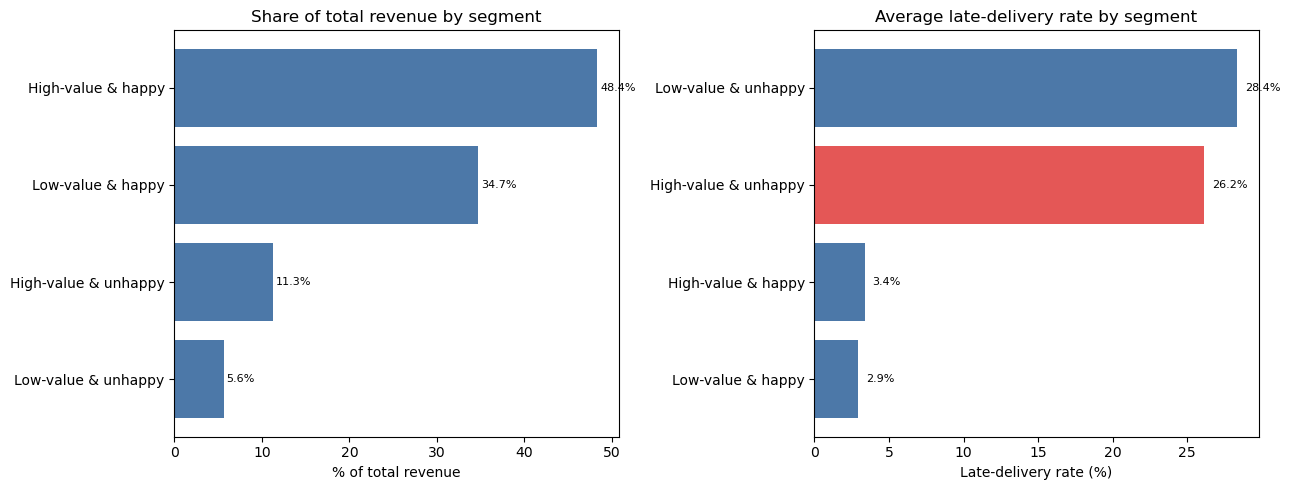

In [15]:
# Break every customer into the 4 value x satisfaction quadrants, to see where the
# priority segment sits relative to the rest of the base.
customers["segment"] = np.select(
    [
        customers["high_value"] & customers["unhappy"],
        customers["high_value"] & ~customers["unhappy"],
        ~customers["high_value"] & customers["unhappy"],
    ],
    ["High-value & unhappy", "High-value & happy", "Low-value & unhappy"],
    default="Low-value & happy",
)

quadrant_summary = (
    customers.groupby("segment")
    .agg(
        customers=("customer_unique_id", "count"),
        revenue_share=("total_payment_value", lambda x: x.sum() / total_revenue * 100),
        late_delivery_rate=("late_delivery_rate", "mean"),
    )
    .sort_values("revenue_share", ascending=False)
)
print(quadrant_summary.round(2))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
order = quadrant_summary.sort_values("revenue_share")
axes[0].barh(order.index, order["revenue_share"], color="#4c78a8")
for y, v in enumerate(order["revenue_share"]):
    axes[0].text(v + 0.3, y, f'{v:.1f}%', va='center', fontsize=8)
axes[0].set(title="Share of total revenue by segment", xlabel="% of total revenue", ylabel="")

order2 = quadrant_summary.sort_values("late_delivery_rate")
colors = ["#e45756" if s == "High-value & unhappy" else "#4c78a8" for s in order2.index]
axes[1].barh(order2.index, order2["late_delivery_rate"] * 100, color=colors)
for y, v in enumerate(order2["late_delivery_rate"] * 100):
    axes[1].text(v + 0.5, y, f'{v:.1f}%', va='center', fontsize=8)
axes[1].set(title="Average late-delivery rate by segment", xlabel="Late-delivery rate (%)", ylabel="")

plt.tight_layout()
plt.show()


The four-way split makes the leverage clear: **high-value & happy customers (48.4% of revenue)**
and **low-value & happy customers (34.7%)** together hold **83% of all revenue at a ~3% late-rate**
— this is the healthy core of the business and the benchmark to protect, not touch. The two
"unhappy" segments are smaller in revenue (11.3% and 5.6%) but run **late-delivery rates roughly
8-9x higher** (26% and 28%) than their happy counterparts. That gap is the whole thesis of this
analysis in one chart: dissatisfaction is not evenly spread across the customer base, it is
concentrated in a delivery-driven minority, and the high-value slice of that minority (~4,200
customers, 11.3% of revenue) is the single highest-leverage place to intervene first.

**~4,200 customers (11.3% of total revenue) are simultaneously high-value and unhappy**, and their
late-delivery rate (~26%) is roughly 8x that of high-value happy customers (~3%). This is a small,
identifiable, high-leverage group: fixing their delivery experience protects real revenue without
requiring a platform-wide overhaul.

### Recommendations

1. **Delivery-promise SLA, protecting the high-value-unhappy cohort first.** The clearest, most
   consistent driver of dissatisfaction across every cut of the data (order, customer, seller,
   state) is delivery delay — fix this first and everything else follows.
2. **Targeted seller and category quality program**, not a blanket policy — audit the small group
   of consistently high-issue-rate sellers, and set category-specific packaging/description
   standards for bulky or fragile goods (bed_bath_table, luggage, furniture, home goods).
3. **Regional logistics intervention in high-late-rate, low-seller-density states (AL, MA, PI)**,
   while treating SP as the operational benchmark to protect, not fix.
4. **Second-order retention nudge conditioned on a clean first delivery** — since the data shows
   delivery experience is where the platform is most likely to lose a customer for good.
5. **Revisit acquisition channel mix** — some high-volume channels (social, email) convert well
   below the funnel average; reallocating spend toward better-converting channels could improve
   seller quality at the source, not just after the fact.

**A note on causality:** every finding above is an *association*, not a proven cause. Delivery delay
correlates strongly and consistently with dissatisfaction across every level of the data we've
checked — which is the strongest kind of evidence a purely observational analysis like this can
offer — but a seller or customer with other, unrelated problems could plausibly show both symptoms
independently. The recommendations above are the most well-supported next actions to *test*, not
settled facts to act on blindly.

### Customer Analysis

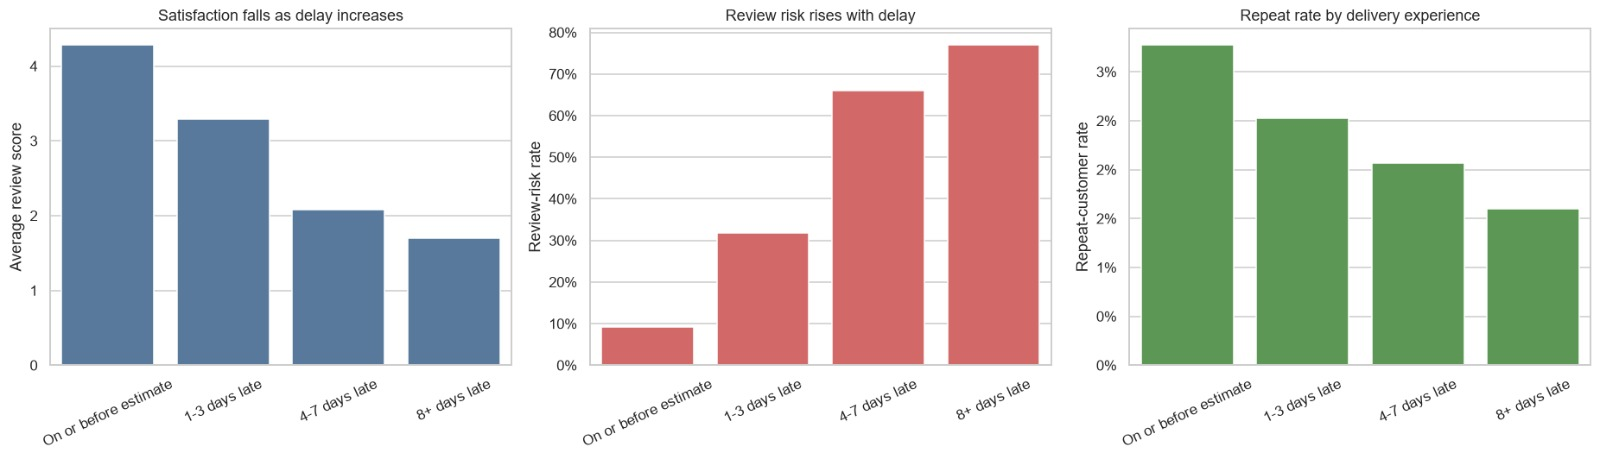

Customer satisfaction falls as delievery delay increases so driving delivery as primary reason of customer dissatisfaction. If there is delivery on time then its has better conversion rate for repeat customer. More the delay in delivery the customer is likely not to buy from the platform again.

              customers  avg_review_score  repeat_rate
late_band                                             
0% late           89597             4.212        0.030
1-33% late           26             3.899        1.000
34-66% late         259             3.079        1.000
67-100% late       6214             2.261        0.005


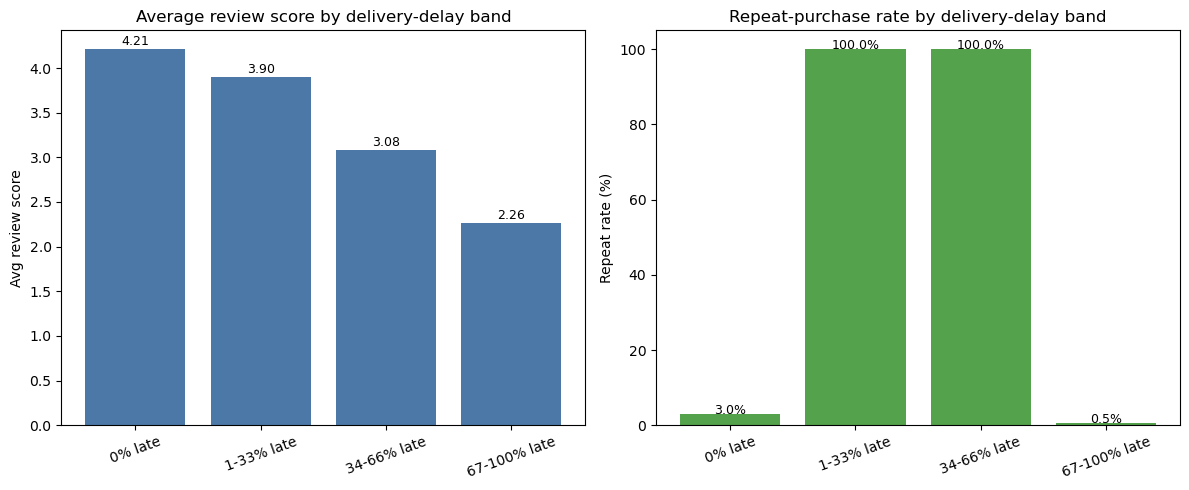

In [16]:
# Live recomputation behind the chart above: bucket customers by their average delivery-delay
# rate and look at review score and repeat-purchase rate in each bucket.
bands = pd.cut(customers['late_delivery_rate'], [-0.01, 0, 0.34, 0.67, 1.01],
               labels=['0% late', '1-33% late', '34-66% late', '67-100% late'])
delay_band_view = (
    customers.assign(late_band=bands)
    .groupby('late_band', observed=True)
    .agg(
        customers=('customer_unique_id', 'count'),
        avg_review_score=('avg_review_score', 'mean'),
        repeat_rate=('repeat_customer_flag', 'mean'),
    )
)
print(delay_band_view.round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].bar(delay_band_view.index.astype(str), delay_band_view['avg_review_score'], color='#4c78a8')
for i, v in enumerate(delay_band_view['avg_review_score']):
    axes[0].text(i, v + 0.05, f'{v:.2f}', ha='center', fontsize=9)
axes[0].set(title='Average review score by delivery-delay band', ylabel='Avg review score', xlabel='')
axes[0].tick_params(axis='x', rotation=20)

axes[1].bar(delay_band_view.index.astype(str), delay_band_view['repeat_rate'] * 100, color='#54a24b')
for i, v in enumerate(delay_band_view['repeat_rate'] * 100):
    axes[1].text(i, v + 0.1, f'{v:.1f}%', ha='center', fontsize=9)
axes[1].set(title='Repeat-purchase rate by delivery-delay band', ylabel='Repeat rate (%)', xlabel='')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()


**Reading the repeat-rate bars carefully — a methodological note.** The "0% late" and
"67-100% late" bands tell the intended story cleanly: customers who never experienced a late
delivery repeat at **3.0%**, while customers whose only/all deliveries were late repeat at just
**0.5%** — a real, large gap, and it sits on the two largest bands (89,597 and 6,214 customers).

The two middle bands ("1-33% late", "34-66% late") show 100% repeat rate, but this is a **sample-
composition artifact, not a genuine finding**: a customer can only have a *fractional* late-delivery
rate (e.g. 33% = 1 late order out of 3) if they placed 2+ orders in the first place — so by
construction, only repeat customers can ever land in these two middle bands, and they are also tiny
(26 and 259 customers vs. tens of thousands in the other two). These two bars should be dropped from
the causal story and are shown here only for transparency about the full distribution.